In [1]:
import pandas as pd
import joblib
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')

In [2]:
# LOAD DATASET
df = pd.read_csv("../dataset/process_data.csv")

In [3]:
# FEATURES AND TARGET
X = df[['burst_time', 'waiting_time', 'remaining_time', 'arrival_time', 'task_type']]
y = df['priority_class']

In [4]:
# CLASS DISTRIBUTION
print("=== CLASS DISTRIBUTION ===")
print(y.value_counts())

=== CLASS DISTRIBUTION ===
priority_class
1    44
2    30
3    20
Name: count, dtype: int64


In [5]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

In [6]:
# MODEL PIPELINE
dnn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(50, 50),
        max_iter=2000,
        activation='relu',
        solver='adam',
        random_state=42
    ))
])

In [7]:
# TRAIN MODEL
dnn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref

In [8]:
# PREDICTIONS
y_pred = dnn_pipeline.predict(X_test)
train_pred = dnn_pipeline.predict(X_train)

In [9]:
# ACCURACY
test_acc = accuracy_score(y_test, y_pred)
train_acc = accuracy_score(y_train, train_pred)

print("\n=== MODEL PERFORMANCE SUMMARY ===")
print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy : {test_acc:.3f}")


=== MODEL PERFORMANCE SUMMARY ===
Train Accuracy: 0.987
Test Accuracy : 0.867


In [10]:
# OVERFITTING CHECK
gap = train_acc - test_acc
print(f"Train-Test Gap: {gap:.3f}")

if gap < 0.05:
    print("Model Generalization: Good")
elif gap < 0.15:
    print("Model Generalization: Mild Overfitting")
else:
    print("Model Generalization: Strong Overfitting")

Train-Test Gap: 0.121
Model Generalization: Mild Overfitting


In [11]:
# CLASSIFICATION REPORT
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           1       1.00      0.71      0.83         7
           2       0.71      1.00      0.83         5
           3       1.00      1.00      1.00         3

    accuracy                           0.87        15
   macro avg       0.90      0.90      0.89        15
weighted avg       0.90      0.87      0.87        15



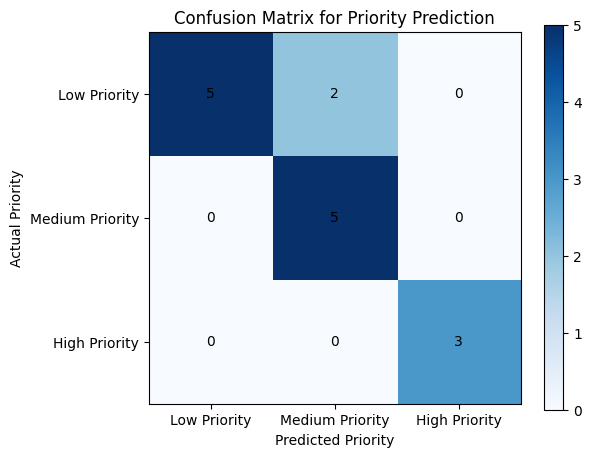

In [12]:
cm = confusion_matrix(y_test, y_pred)

labels = ['Low Priority', 'Medium Priority', 'High Priority']

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='black'
        )

plt.xticks([0, 1, 2], labels)
plt.yticks([0, 1, 2], labels)

plt.xlabel("Predicted Priority")
plt.ylabel("Actual Priority")
plt.title("Confusion Matrix for Priority Prediction")

plt.colorbar()

plt.show()

In [13]:
# CROSS VALIDATION
cv_scores = cross_val_score(dnn_pipeline, X, y, cv=5)

print("\n=== CROSS VALIDATION ===")
print("Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.3f}")
print(f"CV Std Dev      : {cv_scores.std():.3f}")


=== CROSS VALIDATION ===
Scores: [0.89473684 0.73684211 1.         0.89473684 0.83333333]
Mean CV Accuracy: 0.872
CV Std Dev      : 0.086


In [14]:
# SAMPLE PROCESS DECISIONS
print("\n=== SAMPLE PROCESS DECISIONS ===")

sample_processes = X_test.copy()
sample_processes['Actual Priority'] = y_test.values
sample_processes['Predicted Priority'] = y_pred

print(sample_processes.head(10))


=== SAMPLE PROCESS DECISIONS ===
    burst_time  waiting_time  remaining_time  arrival_time  task_type  \
43           2             1               1            10          2   
20           8             0               6             7          0   
61           7             3               6             5          2   
14           7             2               6             4          2   
57           4             3               3             2          1   
91           9             8               8             1          1   
18           7             1               5             6          2   
68           8             4               7             2          0   
38           7             2               6             3          0   
71           7             2               6             3          0   

    Actual Priority  Predicted Priority  
43                1                   1  
20                1                   1  
61                2                 

In [15]:
# AI SCHEDULER INTERPRETATION
print("\n=== AI SCHEDULER INTERPRETATION ===")

for idx, row in sample_processes.head(5).iterrows():
    print(
        f"Process -> "
        f"Burst:{row['burst_time']} | "
        f"Waiting:{row['waiting_time']} | "
        f"Remaining:{row['remaining_time']} | "
        f"TaskType:{row['task_type']} | "
        f"Predicted Priority:{row['Predicted Priority']}"
    )


=== AI SCHEDULER INTERPRETATION ===
Process -> Burst:2 | Waiting:1 | Remaining:1 | TaskType:2 | Predicted Priority:1
Process -> Burst:8 | Waiting:0 | Remaining:6 | TaskType:0 | Predicted Priority:1
Process -> Burst:7 | Waiting:3 | Remaining:6 | TaskType:2 | Predicted Priority:2
Process -> Burst:7 | Waiting:2 | Remaining:6 | TaskType:2 | Predicted Priority:2
Process -> Burst:4 | Waiting:3 | Remaining:3 | TaskType:1 | Predicted Priority:2


In [16]:
# MISCLASSIFIED PROCESSES
print("\n=== MISCLASSIFIED PROCESSES ===")

wrong = sample_processes[
    sample_processes['Actual Priority'] != sample_processes['Predicted Priority']
]

print(wrong)


=== MISCLASSIFIED PROCESSES ===
    burst_time  waiting_time  remaining_time  arrival_time  task_type  \
14           7             2               6             4          2   
38           7             2               6             3          0   

    Actual Priority  Predicted Priority  
14                1                   2  
38                1                   2  


In [18]:
# SAVE MODEL
joblib.dump(dnn_pipeline, "dnn_priority_scheduler.pkl")
print("\nModel saved as dnn_priority_scheduler.pkl")


Model saved as dnn_priority_scheduler.pkl
